### This notebook reproduces the maximum amplification contour plot figure from the paper. The data for the figure are available under max_amplification_outputs directory. This is jut a plotting script. If you want to generate the data use maximum_amplification_grid.py and run this on a cluster.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange
import sys

# plt.style.use("./science.mplstyle")

import smplotlib

codedir = "../src/"

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import griddata

sys.path.append(os.path.abspath(codedir))

from axisymmetric_stability import *

In [2]:
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D
import numpy as np


def overlay_Rafikov_axisymmetric_stability_boundary(
    ax,
    Qg_vec,
    Qs_vec,
    hg,
    hs,
    R,
    sigma=1.5,
    color="black",
    linestyle="solid",
    linewidth=1.5,
    add_legend=False,
    legend_loc="upper right",
):
    """
    Overlay the Rafikov axisymmetric stability boundary on an existing axis.

    Parameters
    ----------
    ax : matplotlib axis
        Axis on which to overlay the boundary.

    Qg_vec, Qs_vec : 1D arrays
        Arrays of Qg and Qs values.

    hg, hs, R : float
        Disk parameters.

    sigma : float
        Gaussian smoothing width.

    add_legend : bool
        If True, add a legend entry for the stability boundary.
    """

    Z = get_stability_boundary_thick_disk(R, Qg_vec, Qs_vec, hg, hs)
    Z_smooth = gaussian_filter(Z, sigma=sigma)

    cs = ax.contour(
        1.0 / Qs_vec,   # x-axis = 1/Qs
        1.0 / Qg_vec,   # y-axis = 1/Qg
        Z_smooth,
        levels=[0.5],
        colors=[color],
        linewidths=linewidth,
        linestyles=linestyle,
        zorder=20,
    )

    if add_legend:
        style_handle = Line2D(
            [0], [0],
            color=color,
            lw=linewidth,
            ls=linestyle,
            label=r"Stability boundary",
        )
        ax.legend(handles=[style_handle], loc=legend_loc)

    return cs

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from matplotlib.lines import Line2D


def plot_max_amplification(
    data_to_plot,
    n_fine=400,
    n_levels=20,
    cmap="turbo",
    save=False,
    filename="max_amplification.pdf",
):
    Qg = np.asarray(data_to_plot["Qg_vec"])
    Qs = np.asarray(data_to_plot["Qs_vec"])
    max_amp = np.asarray(data_to_plot["max_amplification_arr"])

    R = data_to_plot["R"]
    hg = data_to_plot["hg"]
    hs = data_to_plot["hs"]

    # Convert to inverse Q and sort.
    inv_Qg = 1.0 / Qg
    inv_Qs = 1.0 / Qs

    sort_g = np.argsort(inv_Qg)
    sort_s = np.argsort(inv_Qs)

    inv_Qg = inv_Qg[sort_g]
    inv_Qs = inv_Qs[sort_s]

    Qg = Qg[sort_g]
    Qs = Qs[sort_s]

    max_amp = max_amp[np.ix_(sort_g, sort_s)]

    # Original grid.
    X, Y = np.meshgrid(inv_Qs, inv_Qg)

    mask = np.isfinite(max_amp) & (max_amp > 0.0)

    points = np.column_stack((X[mask], Y[mask]))
    values = max_amp[mask]

    if values.size == 0:
        raise ValueError("No positive finite amplification values.")

    # Fine plotting grid.
    x_fine = np.linspace(inv_Qs.min(), inv_Qs.max(), n_fine)
    y_fine = np.linspace(inv_Qg.min(), inv_Qg.max(), n_fine)

    X_fine, Y_fine = np.meshgrid(x_fine, y_fine)

    # Linear interpolation avoids cubic overshooting.
    amp_fine = griddata(
        points,
        values,
        (X_fine, Y_fine),
        method="linear",
    )

    amp_fine = np.ma.masked_invalid(amp_fine)
    amp_fine = np.ma.masked_less_equal(amp_fine, 0.0)

    # Logarithmic color range.
    vmin = max(1.0, np.nanpercentile(values, 2))
    vmax = np.nanmax(values)

    if vmax <= vmin:
        vmax = 1.01 * vmin

    levels = np.geomspace(vmin, vmax, n_levels + 1)
    norm = LogNorm(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(5, 4))

    contour = ax.contourf(
        X_fine,
        Y_fine,
        amp_fine,
        levels=levels,
        norm=norm,
        cmap=cmap,
        extend="neither",
    )

    ax.contour(
        X_fine,
        Y_fine,
        amp_fine,
        levels=levels,
        norm=norm,
        colors="black",
        linewidths=0.35,
        alpha=0.35,
    )

    # Stability boundary.
    stability = get_stability_boundary_thick_disk(
        R,
        Qg,
        Qs,
        hg,
        hs,
    )

    stability = gaussian_filter(stability, sigma=1.5)

    ax.contour(
        inv_Qs,
        inv_Qg,
        stability,
        levels=[0.5],
        colors="black",
        linewidths=1.8,
    )

    # Logarithmic colorbar.
    cbar = fig.colorbar(
        contour,
        ax=ax,
        pad=0.03,
    )

    cbar.set_label(r"max. amplification")

    cbar.locator = LogLocator(
        base=10.0,
        subs=(1.0, 2.0, 5.0),
        numticks=10,
    )

    cbar.formatter = LogFormatterMathtext(base=10.0)
    cbar.update_ticks()

    cbar.ax.tick_params(
        which="both",
        direction="in",
    )

    # Boundary legend.
    boundary_handle = Line2D(
        [0],
        [0],
        color="black",
        linewidth=1.8,
        label="stability boundary",
    )

    ax.legend(
        handles=[boundary_handle],
        frameon=False,
        loc="upper right",
    )

    ax.set_xlabel(r"$1/Q_{\rm s}$")
    ax.set_ylabel(r"$1/Q_{\rm g}$")
    ax.set_title(rf"$R={R}$, $h_s={hs}$, $h_g={hg}$")

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
    )

    if hg < 1.0e-3:
        ax.set_xlim(0.01, 1.1)
        ax.set_ylim(0.01, 1.1)

    fig.tight_layout()

    if save:
        fig.savefig(filename, bbox_inches="tight")

    return fig, ax

In [23]:
def get_data(R,hg,hs):
    
    return np.load(f"./max_amplification_outputs/{R}_{hg}_{hs}.npz")


100
100
100
100
100
100
100
100


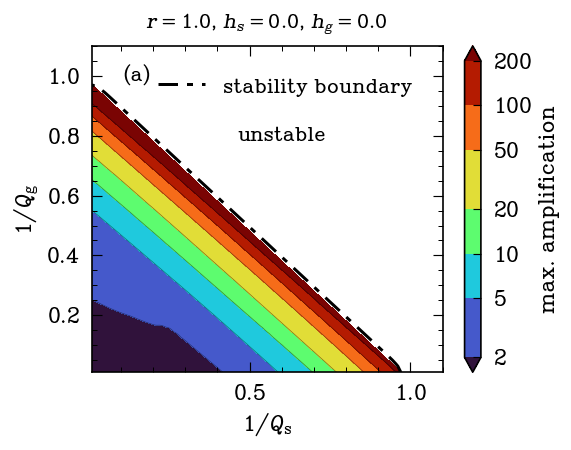

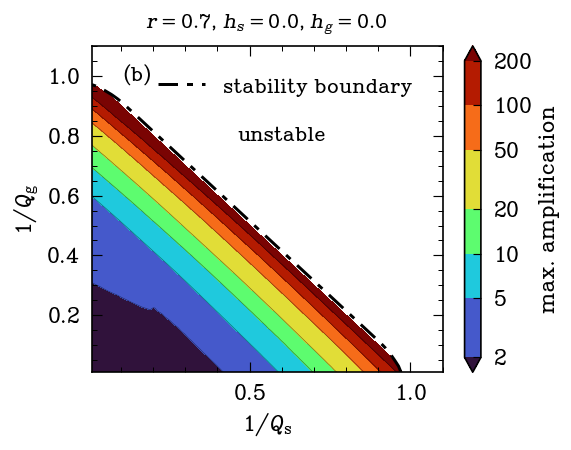

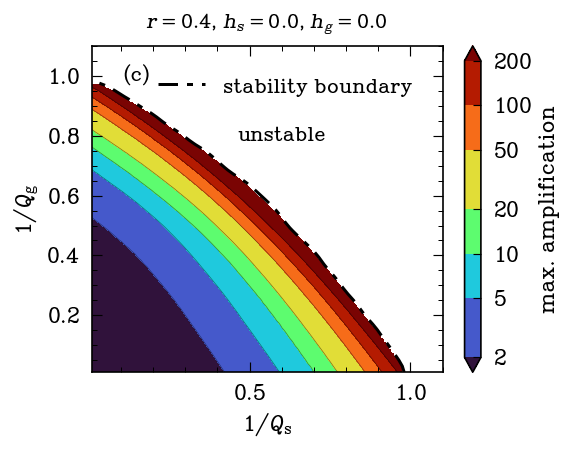

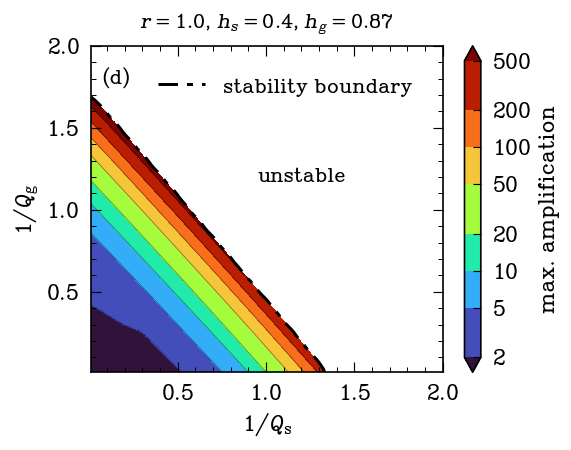

In [24]:
data_values = [[1.0,0.0,0.0, (0.6, 0.8),"(a)", [0.15, 1.0]], 
              [0.7,0.0,0.0, (0.6, 0.8), "(b)", [0.15, 1.0]], 
              [0.4,0.0,0.0, (0.6, 0.8), "(c)", [0.15, 1.0]],
              [1.0,0.87,0.4,(1.2, 1.2), "(d)", [0.15, 1.8]],
              ]

for vals in data_values:
    R = vals[0]
    hg = vals[1]
    hs = vals[2]
    unstable_text_xy = vals[3]
    abcd_text_val = vals[4]
    abcd_text_loc = vals[5]

    data_to_plot = get_data(R,hg,hs)


    fig, ax, boundary = plot_max_amplification_contour_with_Rafikov_boundary(
    data_to_plot,
    boundary_color="black",
     boundary_linestyle="-.",
    boundary_linewidth=1.8,
    save=True,
    filename=f"./Figures/max_amplification_grid_{R}_{hg}_{hs}.pdf",
    # unstable_text_xy=(0.5, 0.8)
    unstable_text_xy=unstable_text_xy,
    abcd_text =1,
    abcd_text_val = abcd_text_val ,
    abcd_text_loc = abcd_text_loc
)

plt.show()